# Group-level sensor-space TRF on real OPM-MEG data

End-to-end walkthrough of TRFlearn on a real cohort: seven participants of a
driving-simulator OPM-MEG experiment (task `DA2`).

A single **jointly fitted** encoding model deconvolves three simultaneous
predictors, each with its own delay window:

| Feature | Source | Window (s) |
| --- | --- | --- |
| `saccades` | saccade onsets (CSV) | (-0.2, 0.5) |
| `steering_wheel` | d/dt of the steering wheel | (-2.0, 2.0) |
| `gas_pedal` | d/dt of the accelerator pedal | (-2.0, 2.0) |

## Steps

1. Build a `TRFData` container per participant.
2. Fit the cohort with `TRFGroup`, one model spec for everyone.
3. Test each feature's kernel against zero with TFCE over subjects.
4. Plot the grand average with its significance shading.

## Data

One folder per participant under `examples/data/OPM/` (git-ignored):

```
<subject>/DA2_<subject>_meg.fif   preprocessed continuous OPM recording
<subject>/saccades.csv            saccade events (onset in seconds, file-relative)
```

Needs `pip install -e ".[mne]"`.


In [1]:
from pathlib import Path
import mne
import numpy as np
import pandas as pd
from trflearn import TRFData, TRFGroup

# MNE reports every annotation step; keep only its warnings.
mne.set_log_level("WARNING")


## 1. Configuration

In [2]:
# Works whether the kernel starts in the repo root or in examples/.
HERE = Path.cwd() if Path.cwd().name == "examples" else Path.cwd() / "examples"
DATA_ROOT = HERE / "data" / "OPM"

# One folder per participant.
SUBJECT_IDS = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())

# Features to be used in the model
FEATURES = ["saccades", "steering_wheel", "gas_pedal"]

# Per-feature delay windows, in seconds
DEFAULT_WINDOW = (-0.2, 0.5)
FEATURE_WINDOWS = {
    "saccades": (-0.2, 0.5),
    "steering_wheel": (-2.0, 2.0),
    "gas_pedal": (-2.0, 2.0)
}

# Extra lags fitted on each side of every window and trimmed off the returned
# kernel, so ridge edge-ringing lands on the margin instead of on the estimate.
DELAY_MARGIN = 0.015

# Ridge parameter hard coded for simplicity
REGULARIZATION = 1
N_FOLDS = 5

# TFCE permutations. With 7 subjects the sign-flip set is exhausted at
# 2**7 = 128, so this is the exact test
N_PERMUTATIONS = 128

# Display-only baseline: the whole window, for every feature
PLOT_BASELINE = (None, None)

# Head sphere pinned to MNE's default radius (m). Left unset, MNE refits it from
# each recording's head-shape points, which moves sensors by ~10% of a head
# radius between subjects and makes topomaps non-comparable.
PLOT_SPHERE = 0.095


## 2. Per-subject loading

Everything the cohort loop needs for one participant, in one function: read the
recording, build the three predictor columns on its own time grid, and wrap them
in a `TRFData`.

The stimulus/behavioural channels are read *before* the sensors are picked, so
they stay available once the recording is narrowed to the magnetometers.

Passing the MNE `Raw` as the target carries the sensor montage into the
container (so kernels export as `Evoked` and draw as topomaps) and lets
TRFlearn drop the "bad"-annotated samples from every fold. No manual masking.

Folds are contiguous, non-shuffled blocks — deliberate for autocorrelated time
series, where a random split would leak neighbouring samples across the
train/test boundary and inflate the score.


In [3]:
# Helper functions to make the input features for the TRF model
def impulse_series(onsets_s: np.ndarray, sfreq: float, n_samples: int) -> np.ndarray:
    """Unit impulses at the given onset times (seconds from recording start)."""
    idx = np.round(np.asarray(onsets_s, dtype=float) * sfreq).astype(int)
    idx = idx[(idx >= 0) & (idx < n_samples)]
    series = np.zeros(n_samples, dtype=np.float64)
    series[idx] = 1.0
    return series

In [4]:
def load_subject(subject_id: str) -> TRFData:
    """Radial magnetometers and the three predictors of one participant."""
    subject_dir = DATA_ROOT / subject_id
    raw = mne.io.read_raw_fif(subject_dir / f"DA2_{subject_id}_meg.fif",
                              preload=False, verbose="ERROR")
    sfreq = raw.info["sfreq"]

    steering = raw.get_data(picks="Steering")[0]
    gas = raw.get_data(picks="Gas")[0]

    # Radial (Z) magnetometers only
    picks = [ch for ch, kind in zip(raw.ch_names, raw.get_channel_types())
             if kind == "mag" and ch.endswith(" Z")]
    meg = raw.copy().pick(picks).load_data(verbose="ERROR")
    n_samples = meg.n_times

    # Onsets in the CSVs are already relative to the file start.
    saccades = pd.read_csv(subject_dir / "saccades.csv")

    features = {
        "saccades": impulse_series(saccades["onset"].to_numpy(), sfreq, n_samples),
        "steering_wheel": np.gradient(steering),
        "gas_pedal": np.gradient(gas),
    }

    # Reshape to the (n_samples, n_subfeatures) layout TRFData expects.
    features = {name: series.reshape(-1, 1) for name, series in features.items()}

    data = TRFData(features=features, y=meg, sample_rate=int(sfreq))
    data.create_partitions(n_folds=N_FOLDS)
    return data


## 3. Fit the cohort

`TRFGroup` holds the model spec once and applies it to every participant, so
the kernels stay comparable across subjects. Each subject is fitted, reduced to
its fold-averaged kernels and channel-wise metric, and the model discarded — only
the summary is kept.

`fit_method="fit"` fits directly at `REGULARIZATION`; `"gridsearch"` would search
`regularization_grid` per subject instead.


In [5]:
group = TRFGroup(
    features=FEATURES,
    cv="pooled",
    default_window=DEFAULT_WINDOW,
    feature_windows=FEATURE_WINDOWS,
    delay_margin=DELAY_MARGIN,
    feature_preprocess="Standardize",
    target_preprocess="Standardize",
    fit_method="fit",
    regularization=REGULARIZATION,
    verbose="warning",     # per-subject status lines would bury the loop below
)

for i, subject_id in enumerate(SUBJECT_IDS, 1):
    print(f"[{i}/{len(SUBJECT_IDS)}] {subject_id}", flush=True)
    group.fit_subject(load_subject(subject_id), subject_id)


[1/7] 10925
[2/7] 16432
[3/7] 17359
[4/7] 17643
[5/7] 17734
[6/7] 18616
[7/7] 18619


## 4. TFCE over subjects

One threshold-free cluster test per feature, asking where its kernel differs
from zero across participants. The test runs over the full
`delays × channels` map, with the delay lattice and the sensor neighbourhood
graph as adjacency, so a real effect can pool evidence over both.

Threshold-free means no cluster-forming *t* to choose, and a genuine p-value at
every point — which is what the figure below shades.

This is the expensive cell: the two ±2 s features carry ~86k test points each.


In [6]:
for feature in FEATURES:
    print(feature, flush=True)
    group.tfce(feature, n_permutations=N_PERMUTATIONS, seed=0, n_jobs=-1)

saccades


D:\OneDrive - UBA\TRFlearn\trflearn\group.py:1213: UserWarning: subjects do not share the same channels; aggregating over the 57 common ones and dropping 7: ['FR4 B2 Z', 'OL6 G7 Z', 'OR5 G5 Z', 'PL3 H4 Z', 'PL6 H5 Z', 'TL6 H1 Z', 'TR2 B5 Z']. See TRFGroup.common_channels.
  warnings.warn(


steering_wheel
gas_pedal


## 5. Figures

One column per feature over the grand average: the kernel butterfly, the
channels × delay image and a topomap. The TFCE result is picked up
automatically — significant delay intervals are shaded green (positive) or red
(negative), the image is greyed out where nothing survives, and the topomap is
drawn at the most significant delay with its significant sensors marked. Baselines are applied on the way to each figure; the stored kernels stay
untouched.

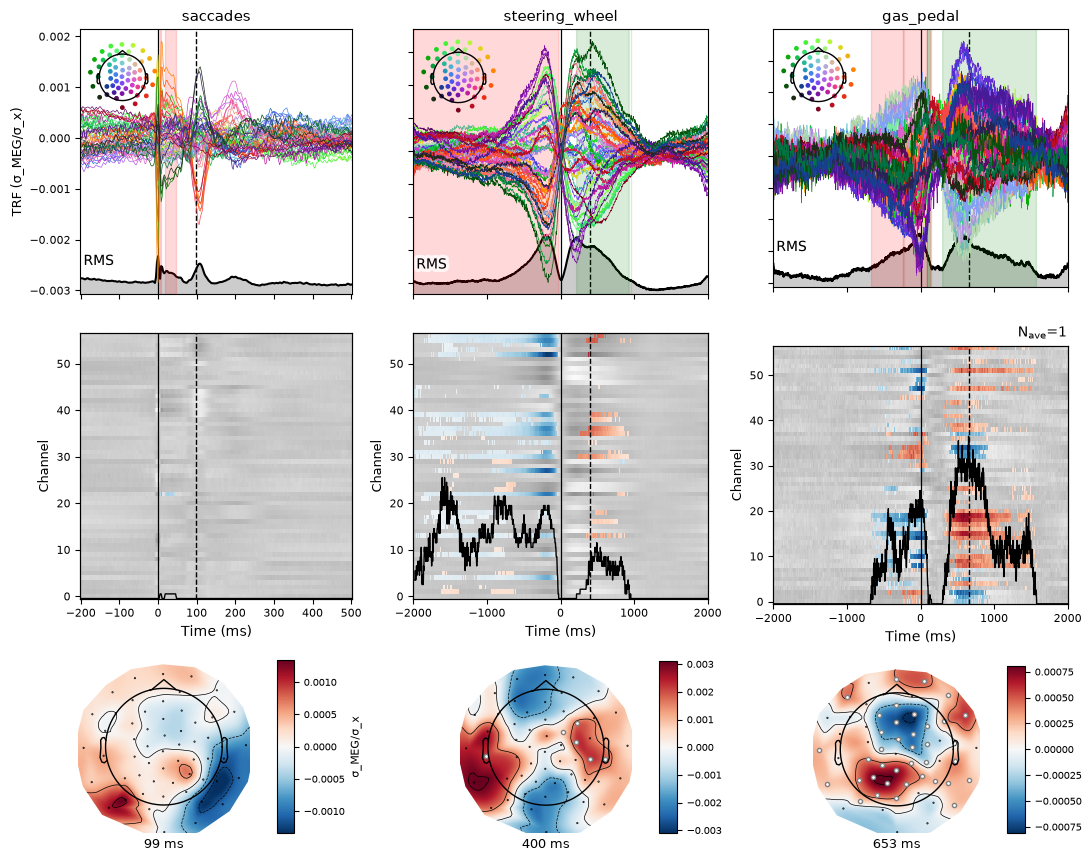

In [7]:
group.plot_baseline = PLOT_BASELINE
group.plot_sphere = PLOT_SPHERE

# Plot all features specifying topography times for saccades and steering
group.plot_features(topo_times={"saccades": 100, "steering_wheel": 400})


MNE evoked object methods prevail

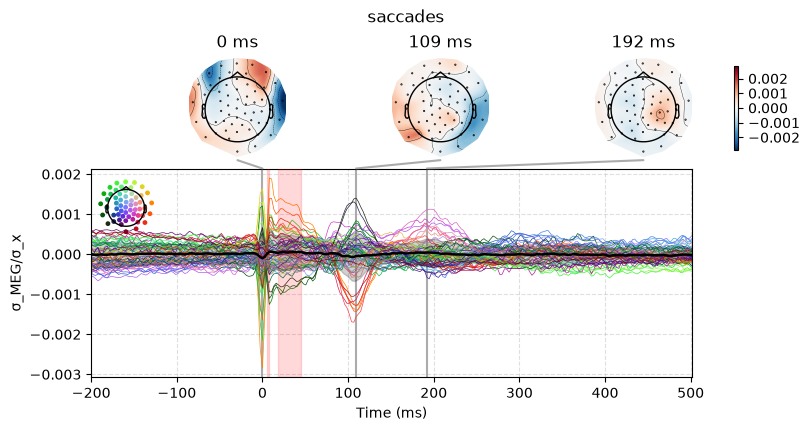

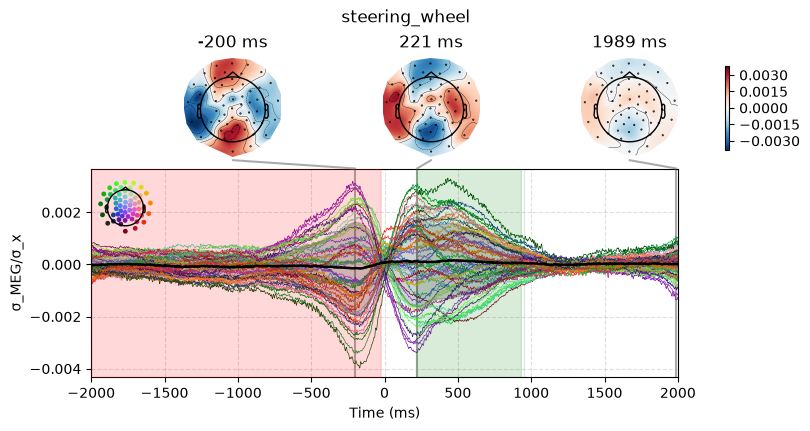

In [9]:
group.plot_joint("saccades", show=True);
group.plot_joint("steering_wheel", show=True);
